<a href="https://colab.research.google.com/github/susu-xxx/MyStudy/blob/DeepLearning/ex01)_%EC%9C%A0%EB%B0%A9%EC%95%94_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#유방암 데이터 데이터셋을 활용한 유방암 예측 모델링 (이진분류)


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

In [28]:
breast_data = load_breast_cancer()
breast_data
# sklearn 제공 데이터셋
# 번치객체 (딕셔너리처럼 활용)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [29]:
# 유방암 데이터 키값 확인
breast_data.keys()

# data : x(입력특성)
# target : y
# target_names  :정답 클래스명
# feature_names : 특성명(컬럼명)
# DESCR : 데이터에 대한 설명 자료

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [30]:
breast_data.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [31]:
# x,y 데이터 분리
x = breast_data.data
y = breast_data.target

In [32]:
pd.Series(y).value_counts()

,count
1,357
0,212


In [33]:
# 비율
pd.Series(y).value_counts( normalize=True)
#1 :양성

,proportion
1,0.627417
0,0.372583


In [34]:
# train, test 분리
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3,
                                                    stratify= y, #train과 test의 클래스 비율 동일하게 유지하여 분할
                                                    random_state=42)

# 머신러닝
1. 문제 정의
2. 데이터 정의
3. 데이터 전처리
4. 탐색적 데이터 분석
5. 모델 선택, 하이퍼 파라미터 튜닝
6. 학습
7. 평가


# 딥러닝

딥러닝 자체에서 특성 공학이 가능
- 3,4 단계에서의 결측치, 이상치 제거 등의 과정이 짧다.

In [35]:
# 도구 불러오기
from tensorflow.keras.models import Sequential #딥러닝 모델의 벼대
from tensorflow.keras.layers import Dense, InputLayer # 딥러닝 모델의 세부 설계

In [36]:
import tensorflow as tf
tf.__version__

'2.18.0'

- 각 층에서 뉴런의 개수를 정하는 데 몇 가지 일반적인 가이드라인 존재
- 하지만 ,최적의 뉴런 개수는 문제의 특성, 데이터의 특성, 모델의 목적에 따라 달라질 수 있음

- 뉴런(unit)개수의 참고용 기준
- 입력 특성의 개수가 많은 경우, 첫번째 은닉층의 뉴런 수를 더 크게 설정
- 고차원 데이터의 경우, 더 많은 뉴런이 필요할수 있다.
- 은닉충의 개수를 늘리면 복잡한 패턴을 학습하는데 도움이 될 수 있지만, 과대적합이 발생할 수 있다.

## 일반적인 경험적 규칙
- 첫번쨰 은닉층 : 입력 특성의 수와 유사한 개수의 뉴런으로시작
- 은닉층의 뉴런 수 줄이기 : 보통 첫번째 은닉층 이후의 층에서 뉴런 수를 점진적으로 줄이는 방법을 사용
- 과대적합 방지 : 누ㅠ런ㅅ의 수가 너무 많으면 과대적합의 위험이 있으므로, 적절한 정규화 기법(L1, L2) 사용 가능  

-교차 검증
- 그리드 서치
-조기 종료ㅕ

In [37]:
model = Sequential()
# 입력층 : Sequentual에 쌓는 첫번쨰 층 , 뉴런 수는 특성의 개수

model.add(InputLayer(shape = (30,)))

#다중 퍼셉트론 구현
#은닉층(중간층)
model.add(Dense(units = 32, activation = 'sigmoid'))
model.add(Dense(units = 64, activation = 'sigmoid'))
model.add(Dense(units = 128, activation = 'sigmoid'))
model.add(Dense(units = 64, activation = 'sigmoid'))
model.add(Dense(units = 32, activation = 'sigmoid'))
model.add(Dense(units = 16, activation = 'sigmoid'))

#뉴런 개수를 정하는 특별한 기준은 없음
# 층을ㅇ 구성하는 데에는 상당한 경험이 필요함

#일반적인 경험에 의하면 효율적인 방법 있음
#항아리 모양: 입력층 : 32 -> 64 > 138 > 64 >32: 출력 층 : 1

#출력층 : 가장 마지막에 있는,  결과를 종합하는 층 / 유닛 수 = 대답해줘야 하는 수 (각각의 확률값)
#출력층에서 사용하는 활성화 함수
# 이진 분류 = sigmoid
# 다중분류 = softmax(각가의 확률)
# 회귀 : linear
model.add(Dense(units = 1, activation='sigmoid'))



In [38]:
#학습 방법 및 평가 방법 설정
model.compile(optimizer='SGD', #최적화 방법 : 확ㄹ류적 경사하강법
                loss='binary_crossentropy',
                metrics=['accuracy'])

In [39]:
#모델 학습
h = model.fit(x_train, y_train,
              validation_split = 0.3,
              epochs = 100)


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6137 - loss: 0.7945 - val_accuracy: 0.6417 - val_loss: 0.7336
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6151 - loss: 0.7674 - val_accuracy: 0.6417 - val_loss: 0.7151
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5826 - loss: 0.7906 - val_accuracy: 0.6417 - val_loss: 0.7004
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6595 - loss: 0.6754 - val_accuracy: 0.6417 - val_loss: 0.6886
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6482 - loss: 0.6792 - val_accuracy: 0.6417 - val_loss: 0.6790
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5840 - loss: 0.7384 - val_accuracy: 0.6417 - val_loss: 0.6723
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6206 - loss: 0.6921 - val_accuracy: 0.6417 - val_loss: 0.6667
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6200 - loss: 0.6859 - val_accuracy: 0.6417 - val_loss:

In [40]:
#a모델 평가
model.evaluate(x_test, y_test)

#손실값, 정확도

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6118 - loss: 0.6682 


[0.661202073097229, 0.6257309913635254]

#### 손실함수(Loss Function) 설정
1. binary_crossentropy(이항 교차 엔트로피)
- y값이 이진분류인 경우 사용되는 손실함수
- 활성화 함수로는 sigmoid 활용

2. categorical_crossentropy (범주형 교차 엔트로피)
- y값이 다중분류인 경우 사용되는 손실함수
- 활성화함수로는 softmax
- 라벨이 (0,1,0,0), (0,0,1,0)과 같이 원핫 인코딩 된 형태로 제공된 경우 활용

3. sparse_categorical_crossentropy
- y값이 다중분류인 경우 사용되는 손실함수
- 활성화함수로는 softmax
- 라벨이 (1,2,3,4)인 경우 사용

4. mean_squared_error (평균 제곱 오차)
- y값이 연속형인 경우 사용되는 손실함수
- 가장 흔하게 쓰임. sparse_categorical_crossentropy
- y값이 다중분류인 경우 사용되는 손실함수
- 활성화함수로는 softmax
- 라벨이 (1,2,3,4)인 경우 사용

4. mean_squared_error (평균 제곱 오차)
- y값이 연속형인 경우 사용되는 손실함수
- 가장 흔하게 쓰임
- 대체로는 MAE(평균 절대 오차),RMSE

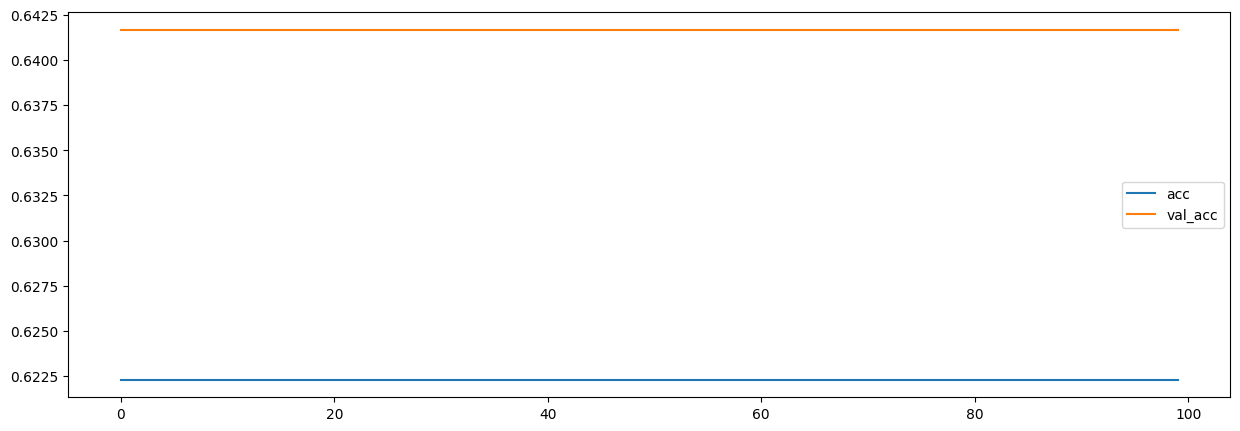

In [43]:
# 시각화
plt.figure(figsize = (15,5))
plt.plot(h.history['accuracy'], label = 'acc') # 훈련데이터의 정확도
plt.plot(h.history['val_accuracy'], label = 'val_acc') # 검증데이터의 정확도
plt.legend()
plt.show()

#시각화 해석
#학습 정확도(acc), 검증 정확도 (val_acc) 모두 거의 일정한 값을 유지하고 있으며, 이 값들은 낮은 수준에 머무르고 있다.
#이러한 패턴은 모델이 학스  되지 않고 있는 상황을 나타냄

# 활성화 함수를 다시 선택, 옵티마이저 선택, 모델 구조 변경, 학습률 조정

In [42]:
h.history['accuracy']

[0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745681763,
 0.6223021745

## 성능 올리기

In [45]:
model2 = Sequential()

model2.add(InputLayer(shape = (30,)))

model2.add(Dense(units = 64, activation = 'relu'))
model2.add(Dense(units = 32, activation = 'relu'))
model2.add(Dense(units = 16, activation = 'relu'))

model2.add(Dense(units = 1, activation='sigmoid')) #이진분류기 때문에 시그모이드 유지!



In [47]:
#학습 방법 및 평가 방법 설정
model2.compile(optimizer='adam', #SGD 업그레이드 버전 : 각 파라미터에 맞는 적응형 학습률을 적용
                loss='binary_crossentropy',
                metrics=['accuracy']) # 평가지표 : 분류 (정확도/accuracy)

In [48]:
#모델 학습
h = model2.fit(x_train, y_train,
              validation_split = 0.3,
              epochs = 100)


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.4445 - loss: 16.4014 - val_accuracy: 0.6417 - val_loss: 2.8484
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4704 - loss: 2.4773 - val_accuracy: 0.3583 - val_loss: 0.9503
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6908 - loss: 0.9388 - val_accuracy: 0.3917 - val_loss: 0.9077
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5588 - loss: 0.8418 - val_accuracy: 0.8500 - val_loss: 0.4182
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8270 - loss: 0.4051 - val_accuracy: 0.9167 - val_loss: 0.2355
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8929 - loss: 0.3105 - val_accuracy: 0.9250 - val_loss: 0.2242
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9286 - loss: 0.2626 - val_accuracy: 0.9000 - val_loss: 0.2483
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8839 - loss: 0.2919 - val_accuracy: 0.9083 - val_loss

In [50]:
#a모델 평가
model2.evaluate(x_test, y_test)

#손실값, 정확도

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9420 - loss: 0.1963 


[0.20676201581954956, 0.9298245906829834]

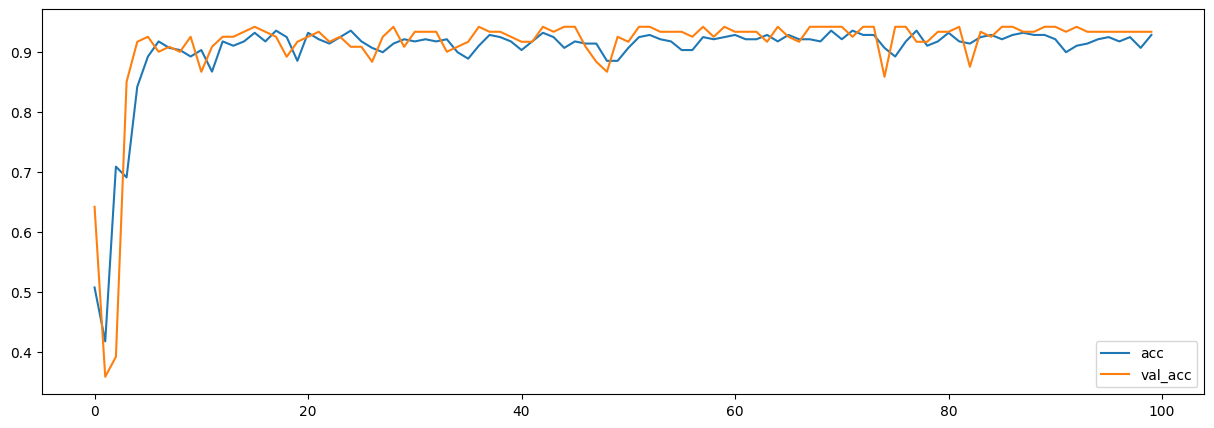

In [51]:
plt.figure(figsize = (15,5))
plt.plot(h.history['accuracy'], label = 'acc') # 훈련데이터의 정확도
plt.plot(h.history['val_accuracy'], label = 'val_acc') # 검증데이터의 정확도
plt.legend()
plt.show()

In [53]:
# 초기 몇 epoch 동안은 정확도가 급격하게 변화, 원래 그럼
#에포크가 진행될수록  불안정한 구간도 있지만, 점차 안정화를 되찾아감